In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA


In [ ]:
# Load
train = pd.read_csv("./Data/sign_mnist_train.csv")
test = pd.read_csv("./Data/sign_mnist_test.csv")

# Split
X_train = train.drop("label", axis=1)
y_train = train["label"]

X_test = test.drop("label", axis=1)
y_test = test["label"]

In [24]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((27455, 784), (27455,), (7172, 784), (7172,))

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

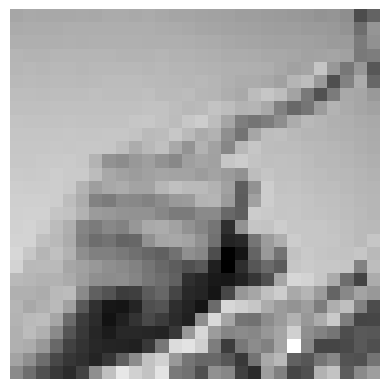

In [25]:
# display image data
some_image = X_train.iloc[1].to_numpy().reshape(28, 28)
plt.imshow(some_image, cmap="gray")
y_train.iloc[1]
plt.axis("off")


In [26]:
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

## RandomForestClassifier

In [27]:
# Model
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8119074177356386


In [30]:
import joblib

joblib.dump(rf, "rf_model.pkl")

['rf_model.pkl']

## CNN

In [42]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [43]:
# Load data
train = pd.read_csv("./Data/sign_mnist_train.csv")
test = pd.read_csv("./Data/sign_mnist_test.csv")

X_train = train.drop("label", axis=1).values
y_train = train["label"].values

X_test = test.drop("label", axis=1).values
y_test = test["label"].values



In [44]:
# =========================
# 2. FIX LABELS (IMPORTANT)
# =========================
unique_labels = sorted(np.unique(y_train))
label_map = {label: idx for idx, label in enumerate(unique_labels)}

y_train = np.array([label_map[y] for y in y_train])
y_test  = np.array([label_map[y] for y in y_test])

# save mapping 
import joblib
joblib.dump(label_map, "label_map.pkl")


['label_map.pkl']

In [45]:
# =========================
# 3. PREPROCESSING
# =========================
X_train = X_train / 255.0
X_test  = X_test / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)


In [46]:
# =========================
# 4. DATA AUGMENTATION
# =========================
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)


In [47]:
# =========================
# 5. MODEL
# =========================
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(24, activation='softmax')
])


c:\Users\marwa\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
# =========================
# 5. MODEL
# =========================
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(24, activation='softmax')
])


# =========================
# 6. COMPILE
# =========================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# =========================
# 7. CALLBACKS
# =========================
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-5
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)




In [50]:
# =========================
# 8. TRAIN
# =========================
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, lr_reduce, checkpoint]
)




Epoch 1/20
857/858 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4435 - loss: 1.8351

858/858 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.6565 - loss: 1.0881 - val_accuracy: 0.6235 - val_loss: 1.7101 - learning_rate: 0.0010
Epoch 2/20
857/858 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8960 - loss: 0.3150

858/858 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.9156 - loss: 0.2525 - val_accuracy: 0.9813 - val_loss: 0.0462 - learning_rate: 0.0010
Epoch 3/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9583 - loss: 0.1239 - val_accuracy: 0.9803 - val_loss: 0.0625 - learning_rate: 0.0010
Epoch 4/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9699 - loss: 0.0934 - val_accuracy: 0.9527 - val_loss: 0.1751 - learning_rate: 0.0010
Epoch 5/20
857/858 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9874 - loss: 0.0434

858/858 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.9897 - loss: 0.0344 - val_accuracy: 0.9975 - val_loss: 0.0054 - learning_rate: 3.0000e-04
Epoch 6/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.9941 - loss: 0.0204 - val_accuracy: 0.9943 - val_loss: 0.0145 - learning_rate: 3.0000e-04
Epoch 7/20
856/858 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9943 - loss: 0.0181

858/858 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9945 - loss: 0.0186 - val_accuracy: 0.9992 - val_loss: 0.0038 - learning_rate: 3.0000e-04
Epoch 8/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.9947 - loss: 0.0174 - val_accuracy: 0.9964 - val_loss: 0.0099 - learning_rate: 3.0000e-04
Epoch 9/20
857/858 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9940 - loss: 0.0170

858/858 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9942 - loss: 0.0166 - val_accuracy: 0.9999 - val_loss: 0.0011 - learning_rate: 3.0000e-04
Epoch 10/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.9952 - loss: 0.0163 - val_accuracy: 0.9994 - val_loss: 0.0017 - learning_rate: 3.0000e-04
Epoch 11/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.9954 - loss: 0.0150 - val_accuracy: 0.9757 - val_loss: 0.1260 - learning_rate: 3.0000e-04
Epoch 12/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9976 - loss: 0.0088 - val_accuracy: 0.9999 - val_loss: 6.1860e-04 - learning_rate: 9.0000e-05


In [51]:
# =========================
# 9. EVALUATE
# =========================
loss, acc = model.evaluate(X_test, y_test)
print("Final Accuracy:", acc)




225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9999 - loss: 0.0011
Final Accuracy: 0.9998605847358704


In [52]:
# =========================
# 10. SAVE FINAL MODEL
# =========================
model.save("cnn_model_final.h5")